# use mapping310 env

In [13]:
import geopandas as gpd
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
from rapidfuzz import fuzz, process


In [14]:
df = pd.read_csv('MeasuredSectionStats.csv')

facies_colors = pd.read_excel('./MeasuredSections/_fromDropbox/Facies Rosetta Stone.xlsx')
code_col = 'facies_code_MOST'
color_col = 'color_hex_measured_section'
name_col = 'name' if 'name' in facies_colors.columns else facies_colors.columns[0]
name_ms_col = 'name_measured_section' if 'name_measured_section' in facies_colors.columns else name_col
fc = facies_colors.dropna(subset=[code_col]).drop_duplicates(subset=[code_col], keep='first')
facies_color_map = dict(zip(fc[code_col].astype(int), fc[color_col].astype(str)))
facies_label_map = dict(zip(fc[code_col].astype(int), fc[name_col].astype(str)))
facies_name_ms_map = dict(zip(fc[code_col].astype(int), fc[name_ms_col].astype(str)))


In [15]:
# Load gdf if not already loaded (GeoJSON has NAME column)
gdf = gpd.read_file('geojsonWGS84/measured_sections_all_areas.geojson')
gdf_name_col = 'NAME' if 'NAME' in gdf.columns else 'name'

# Fuzzy match df['name'] to gdf name column
df_names = df['name'].dropna().unique().tolist()
gdf_names = gdf[gdf_name_col].dropna().unique().tolist()

# Build mapping: df_name -> (best_gdf_match, score)
# Use token_sort_ratio for "ArrowCanyon" vs "Arrow Canyon" type matches
name_to_gdf = {}
for dn in df_names:
    match, score, _ = process.extractOne(dn, gdf_names, scorer=fuzz.token_sort_ratio)
    name_to_gdf[dn] = (match, score)

# Add matched name to df for merging
df['name_matched'] = df['name'].map(lambda x: name_to_gdf.get(x, (None, 0))[0])
df['match_score'] = df['name'].map(lambda x: name_to_gdf.get(x, (None, 0))[1])

# Optional: show low-confidence matches (score < 90)
low_conf = [(k, v[0], v[1]) for k, v in name_to_gdf.items() if v[1] < 90]
if low_conf:
    print("Low-confidence matches (review manually):")
    for df_n, gdf_n, sc in sorted(low_conf, key=lambda x: x[2]):
        print(f"  {df_n!r} -> {gdf_n!r} (score={sc})")

# Merge df with gdf on matched names (keeps geometry from gdf)
gdf_renamed = gdf.rename(columns={gdf_name_col: 'name_matched'})
merged = df.merge(gdf_renamed, on='name_matched', how='left')

Low-confidence matches (review manually):
  'HOTMONDAY' -> 'DNA lap A' (score=22.22222222222222)
  'LONGWALK' -> 'DNA lap A' (score=23.529411764705888)
  'Fbm' -> 'Fan 4 Graben' (score=26.66666666666667)
  'Fbm_1' -> 'LobeWall1' (score=28.57142857142857)
  'ColSec08jmc.CNV_p' -> 'North V Section' (score=31.25)
  'FBc2' -> 'N2' (score=33.333333333333336)
  'ColSec08ANEW' -> 'Colleen B' (score=38.095238095238095)
  'W1a' -> 'M1' (score=40.0)
  'W2a' -> 'N2' (score=40.0)
  'W2b' -> 'N2' (score=40.0)
  'W3a' -> 'N3' (score=40.0)
  'W3b' -> 'N3' (score=40.0)
  'W3c' -> 'N3' (score=40.0)
  'SognefjordBend' -> 'Wergeland Creek Section' (score=43.24324324324324)
  'WegerlandCreek' -> 'Powertank' (score=43.47826086956522)
  'ColSec13rev2002new' -> 'Colleen B' (score=44.44444444444444)
  'OFR1' -> 'SDMR1' (score=44.44444444444444)
  'OFR2' -> 'SDMR2' (score=44.44444444444444)
  'ColSec09' -> 'Colleen B' (score=47.05882352941176)
  'Roadcut2_new2004_jb' -> 'Roadcut 2r' (score=48.275862068965516)


In [ ]:
df

,name,Facies,bed_count,total_thickness,mean_thickness,min_thickness,max_thickness,mean_grainsize,min_grainsize,max_grainsize,thickness_list,section_total_thickness,name_matched,match_score
0,ArrowCanyon,1,2,0.5335,0.266750,0.2510,0.2825,3.573889,2.88,4.06,"[0.251, 0.2825]",77.55,Arrow Canyon,95.652174
1,ArrowCanyon,2,3,1.5065,0.502167,0.1884,0.8788,3.593254,3.06,3.81,"[0.1884, 0.8788, 0.4393]",77.55,Arrow Canyon,95.652174
2,ArrowCanyon,3,1,1.1612,1.161200,1.1612,1.1612,3.779459,2.94,3.81,[1.1612],77.55,Arrow Canyon,95.652174
3,ArrowCanyon,4,4,7.8460,1.961500,0.3452,3.7661,4.009343,3.49,4.20,"[3.7661, 2.4794, 1.2553, 0.3452]",77.55,Arrow Canyon,95.652174
4,ArrowCanyon,5,31,25.7973,0.832171,0.1569,2.2911,3.787743,2.88,4.83,"[0.1883, 0.3452, 0.9101, 2.2911, 0.1883, 1.632...",77.55,Arrow Canyon,95.652174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,WestBrushyMesa,10,25,8.1479,0.325916,0.0800,1.0885,3.861822,2.86,4.50,"[0.3041, 0.4002, 0.4002, 0.5443, 0.1281, 0.272...",103.12,West Brushy Mesa,66.666667
958,WestBrushyMesa,12,3,0.5602,0.186733,0.1120,0.2721,3.633333,3.28,4.01,"[0.112, 0.2721, 0.1761]",103.12,West Brushy Mesa,66.666667
959,WestBrushyMesa,14,50,36.0319,0.720638,0.0480,5.1384,2.833400,2.80,2.86,"[5.1384, 0.064, 0.2561, 0.2401, 0.2561, 0.128,...",103.12,West Brushy Mesa,66.666667
960,WestBrushyMesa,15,7,0.7206,0.102943,0.0160,0.1281,2.970000,2.80,3.67,"[0.1281, 0.1121, 0.016, 0.1121, 0.1121, 0.1121...",103.12,West Brushy Mesa,66.666667


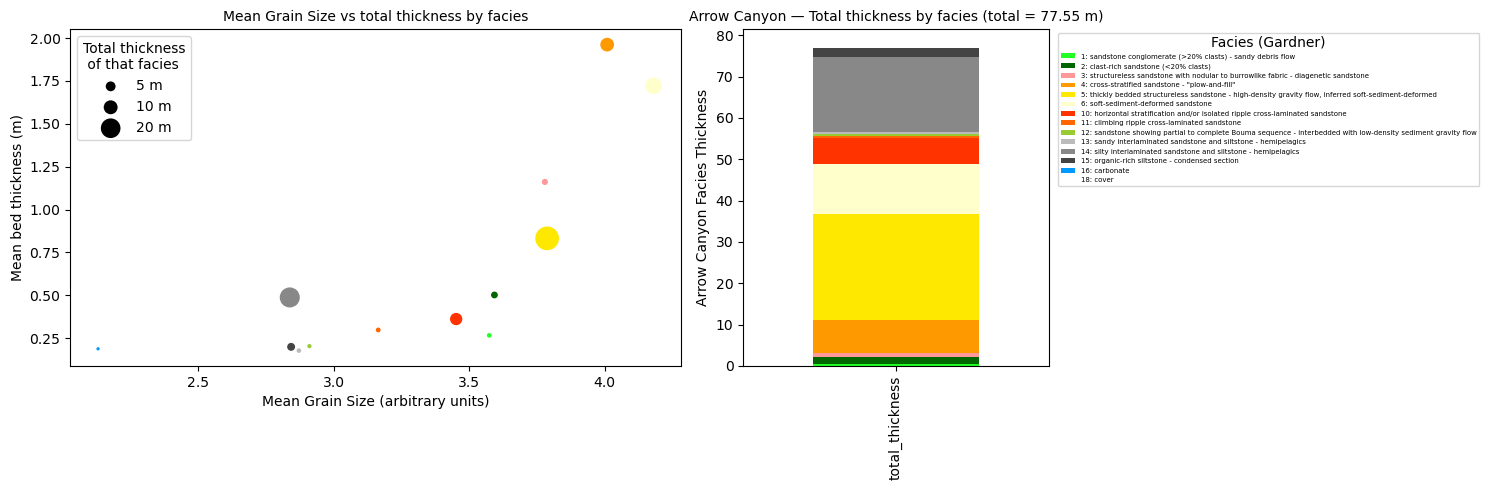

In [4]:
# Filter to Arrow Canyon
arrow = df[df['name'] == 'ArrowCanyon'].copy()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

# Subplot 0: scatter (mean grainsize vs total thickness)
arrow_scatter_colors = arrow['Facies'].map(facies_color_map).fillna('#cccccc')
arrow.plot(kind='scatter', x='mean_grainsize', y='mean_thickness', c=arrow_scatter_colors, s=arrow['total_thickness'] * 10, ax=ax0)
ax0.set_xlabel('Mean Grain Size (arbitrary units)')
ax0.set_ylabel('Mean bed thickness (m)')
ax0.set_title('Mean Grain Size vs total thickness by facies', fontsize=10)
# Size legend: black circles showing what thickness each size represents (same scale s=thickness*10)
size_legend_m = [5, 10, 20]
for t in size_legend_m:
    ax0.scatter([], [], s=t * 10, c='black', label=f'{t} m', edgecolors='none')
ax0.legend(loc='upper left', title='Total thickness\n of that facies')

# Subplot 1: stacked bar of total thickness by facies
stacked = arrow.set_index('Facies')['total_thickness'].to_frame().T
colors = [facies_color_map.get(f, '#cccccc') for f in stacked.columns]
stacked.plot(kind='bar', stacked=True, ax=ax1, color=colors, legend=True, width=0.6)
section_total = arrow['section_total_thickness'].iloc[0] if 'section_total_thickness' in arrow.columns else stacked.values.sum()
ax1.set_ylabel('Arrow Canyon Facies Thickness')
ax1.set_title(f'Arrow Canyon — Total thickness by facies (total = {section_total:.2f} m)', fontsize=10)
legend_labels = [f"{f}: {facies_name_ms_map.get(f, str(f))}" for f in stacked.columns]
leg = ax1.get_legend()
if leg:
    ax1.legend(leg.legend_handles, legend_labels, title='Facies (Gardner)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=5)

plt.tight_layout()
plt.show()



In [6]:
df.name.unique()

array(['ArrowCanyon', 'BadGirlsGully', 'BadtotheBone', 'BitterwellCynNE',
       'BloodSweatandTears', 'BrushyMesaFaultBlock', 'BurroN',
       'ChannelWall1', 'ChannelWall2', 'ChannelWall3NE',
       'CodornizCanyon1', 'CodornizCanyon2', 'CodornizCanyon2Annex',
       'CodornizCanyon3', 'ColSec08ANEW', 'ColSec08jmc.CNV_p', 'ColSec09',
       'ColSec13rev2002new', 'Colleen02', 'Colleen04', 'Colleen06',
       'Colleen1', 'Colleen10', 'Colleen12', 'Colleen14', 'Colleen14a',
       'Colleen15', 'Colleen15(2ndrun)', 'Colleen1_1', 'Colleen3',
       'Colleen5', 'Colleen7', 'ColleenCanyon08', 'ColleenCanyon4.5',
       'CookyPtSouth', 'DanceHall', 'DanceHallEast',
       'DancingDutchSandwich', 'EagleNest', 'FBc2', 'FaultWall2', 'Fbm',
       'Fbm_1', 'GardnersFolly', 'GnatGrabenGulley', 'HOTMONDAY',
       'Hoagie', 'HogueCanyon', 'HogueWest', 'HotMondayChannelAxis',
       'JanesWindowA', 'JanesWindowB', 'LONGWALK', 'LobeWall1',
       'LobeWall2_dp', 'LowerChannel', 'LwrCodornizAnnex',
 

In [12]:
gdf = gpd.read_file('geojsonWGS84/measured_sections_all_areas.geojson')
sorted([name for name in gdf.NAME.unique() if name is not None])

['4.3 Retrofit Axis',
 '4.3 Retrofit Margin',
 'Angry Goat',
 'Annie 1 Colleen W. Face',
 'Annie 2',
 'Annie 3',
 'Apache Tanks',
 'Arrow Canyon',
 'Arruga',
 'BMS',
 'BV Axis',
 'BV Lower',
 'BV Margin',
 'BV South',
 'BV South Lower',
 'Bad Girls Gully',
 'Bad to the Bone',
 'Barbary Gully',
 'Bat Mobile (Channel Canyon)',
 'Behind Roadcut Gully',
 'Bittersweet',
 'Bittersweet Composite',
 'Bittersweet Repeat',
 'Bitterwell Cyn_NE',
 'Bloated Goat',
 'Blood, Sweat and Tears',
 'Bone Canyon',
 'Brushy Mesa (0.5 base)',
 'Brushy Mesa Beehive (BM)',
 'Brushy Mesa Fault Block',
 'Brushy Mesa North Rerun',
 'Buck Canyon',
 'Buck Canyon Annex',
 'Buck Canyon Extension',
 'Buck Canyon Revision',
 'Buck Mesa East',
 'Buck Mesa East 2',
 'Buck Mesa West',
 'Buck Nose',
 'Bull',
 'Burrow North',
 'Carole Canyon',
 'Cascade Section',
 'Center',
 'Central Bitterwell Canyon',
 'Channel Block North',
 'Channel Block South',
 'Channel Wall 1',
 'Channel Wall 1a',
 'Channel Wall 2',
 'Channel Wall 2